In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Polygon
from matplotlib.patches import Rectangle
import numpy as np

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
fontManager.addfont(font_path)

normal_font = FontProperties(fname=font_path)
italic_font = FontProperties(fname=ifont_path)
title_font = FontProperties(fname=ifont_path, size=10)

font_name = normal_font.get_name()
plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

In [2]:
import os
import pandas as pd

genus_name = 'Escherichia'
max_name = 'GCF_022569795.1'
acc_n = max_name
seq_record_id = 'NZ_CP093011.1'

data_folder = f'/active-data/analysis_results/chr_pla/genus/max_matched/{genus_name}/{acc_n}'
head = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
align_result = pd.read_csv(f'{data_folder}/blastn_results_{acc_n}_{seq_record_id}.txt', sep = '\t|;', engine = 'python', header = None, names = head)
temp_result = align_result[(align_result['pident'] >= 90)]

oric_pd = pd.read_csv(f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}/Ori_finder/oriC_ORCA/{max_name}/{seq_record_id}.csv')
max_pred_row = oric_pd.loc[oric_pd['predictions'].idxmax()]
oric_site = max_pred_row['oriC_middles']

result_dir = f'/active-data/analysis_results/chr_pla/genus/figure_data/example_coverage/{genus_name}'

filted = True
if filted:
    suffix = '_filted'
else:
    suffix = ''

trans_file = os.path.join(result_dir, f"{max_name}_trans_coverage{suffix}.txt")
typical_file = os.path.join(result_dir, f"{max_name}_typical_coverage{suffix}.txt")

trans_coverage = np.loadtxt(trans_file, dtype=int)
typical_coverage = np.loadtxt(typical_file, dtype=int)
seq_len = len(trans_coverage)
id_score_df = pd.read_csv(f"{result_dir}/{max_name}_id_score_df{suffix}.csv")
transi_score_df = id_score_df[id_score_df["average plasmid fraction-pident_90"] < 0.3]
typical_score_df = id_score_df[id_score_df["average plasmid fraction-pident_90"] >= 0.3]

In [3]:
def find_enriched_regions(arr, window_size=10000, step=1000, threshold_mode="ratio", threshold=0.1, method="mean", gap_merge=50000):
    max_pos = len(arr)
    starts = np.arange(0, max_pos, step)
    ends = starts + window_size
    ends[ends > max_pos] = max_pos

    window_vals = []
    for s, e in zip(starts, ends):
        window = arr[s:e]
        if method == "sum":
            val = window.sum()
        elif method == "mean":
            val = window.mean() if len(window) > 0 else 0
        window_vals.append(val)
    
    window_vals = np.array(window_vals)
    
    if threshold_mode == "quantile":
        threshold_val = np.quantile(window_vals, threshold)
    elif threshold_mode == "ratio":
        val_min = window_vals.min()
        val_max = window_vals.max()
        threshold_val = val_min + (val_max - val_min) * threshold
    enriched_mask = window_vals > threshold_val

    enr_starts = starts[enriched_mask]
    enr_ends = ends[enriched_mask]

    if len(enr_starts) == 0:
        return []
    
    order = np.argsort(enr_starts)
    s = enr_starts[order]
    e = enr_ends[order]
    
    merged = [(s[0], e[0])]
    for i in range(1, len(s)):
        last_s, last_e = merged[-1]
        curr_s, curr_e = s[i], e[i]
        
        if curr_s <= last_e + gap_merge:
            merged[-1] = (last_s, max(last_e, curr_e))
        else:
            merged.append((curr_s, curr_e))
    
    return merged

def interval_intersection(a_intervals, b_intervals):
    intersections = []
    i = j = 0
    a = sorted(a_intervals)
    b = sorted(b_intervals)
    while i < len(a) and j < len(b):
        a_start, a_end = a[i]
        b_start, b_end = b[j]
        start = max(a_start, b_start)
        end = min(a_end, b_end)
        if start < end:
            intersections.append((start, end))
        if a_end < b_end:
            i += 1
        else:
            j += 1
    return intersections

def interval_subtract(intervals, to_remove):
    result = []
    for s, e in intervals:
        current = [(s, e)]
        for r_s, r_e in to_remove:
            new_current = []
            for c_s, c_e in current:
                if c_e <= r_s or c_s >= r_e:
                    new_current.append((c_s, c_e))
                else:
                    if c_s < r_s:
                        new_current.append((c_s, r_s))
                    if c_e > r_e:
                        new_current.append((r_e, c_e))
            current = new_current
        result.extend(current)
    return result

trans_enriched = find_enriched_regions(trans_coverage, threshold=0.1)
typical_enriched = find_enriched_regions(typical_coverage, threshold=0.1)

common_intervals = interval_intersection(trans_enriched, typical_enriched)

trans_unique = interval_subtract(trans_enriched, common_intervals)
typical_unique = interval_subtract(typical_enriched, common_intervals)

In [4]:
def merge_continuous_regions(arr):
    regions = []
    if len(arr) == 0:
        return regions
    current_val = arr[0]
    start_idx = 0
    for i in range(1, len(arr)):
        if arr[i] != current_val:
            regions.append((start_idx+1, i, current_val))
            current_val = arr[i]
            start_idx = i
    regions.append((start_idx+1, len(arr), current_val))
    return regions

trans_regions = merge_continuous_regions(trans_coverage)
trans_regions = [r for r in trans_regions if r[2]>0]

typical_regions = merge_continuous_regions(typical_coverage)
typical_regions = [r for r in typical_regions if r[2]>0]

In [5]:
from Bio import SeqIO

def gene_type_count(acc_n, seq_record_id, region_list):
    COG_data_dir = '/active-data/datasets/COG_data'
    COG_table = pd.read_csv(f'{COG_data_dir}/cog-24.def.tsv', sep='\t')
    COG_info = pd.read_csv(f'{COG_data_dir}/cog-24.fun.tsv', sep='\t')
    cog2cat = dict(zip(COG_table["COG_ID"], COG_table["Functional_Category"]))

    def process_ogs(ogs_str):
        if pd.isna(ogs_str) or 'COG' not in ogs_str:
            return ''
        
        og_list = ogs_str.split(',')
        cog_set = set()
        for og in og_list:
            if 'COG' in og:
                cog = og.split('@')[0]
                cog_set.add(cog)
        
        cat_chars = set()
        for cog in cog_set:
            if cog in cog2cat:
                cat_chars.update(cog2cat[cog])
        
        return ''.join(sorted(cat_chars))
    
    head = 'query	seed_ortholog	evalue	score	eggNOG_OGs	max_annot_lvl	COG_category	Description	Preferred_name	GOs	EC	KEGG_ko	KEGG_Pathway	KEGG_Module	KEGG_Reaction	KEGG_rclass	BRITE	KEGG_TC	CAZy	BiGG_Reaction	PFAMs'.split('\t')
    eggnog_re = pd.read_csv(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/eggnog_results/{acc_n}/{acc_n}.emapper.annotations', comment = '#', sep = '\t', header = None, names = head)
    eggnog_re['COG_category_new'] = eggnog_re['eggNOG_OGs'].apply(process_ogs)
    
    mask = (eggnog_re['COG_category_new'] != '') & (eggnog_re['COG_category_new'] != eggnog_re['COG_category'])
    eggnog_re['COG_category_corrected'] = np.where(mask, eggnog_re['COG_category_new'], eggnog_re['COG_category'])
    
    handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
    seq_record = SeqIO.parse(handle, 'genbank')
    for record in seq_record:
        if record.id == seq_record_id:
            target_record = record
            break
    CDS_count = {'CDSs (total)': 0, 'CDSs (with protein)': 0, 'CDSs (without protein, Pseudo Genes)': 0}
    protein_ids = []
    if region_list:
        for s, e in region_list:
            temp_record = record[s:e]
            for feature in temp_record.features:
                if feature.type == 'CDS':
                    CDS_count['CDSs (total)'] += 1
                    if 'translation' in feature.qualifiers:
                        CDS_count['CDSs (with protein)'] += 1
                        protein_ids.append('-'.join([acc_n, seq_record_id, feature.qualifiers['locus_tag'][0]]))
                    else:
                        CDS_count['CDSs (without protein, Pseudo Genes)'] += 1

        temp_eggnog = eggnog_re[eggnog_re['query'].isin(protein_ids)]
    else:
        for feature in record.features:
            if feature.type == 'CDS':
                CDS_count['CDSs (total)'] += 1
                if 'translation' in feature.qualifiers:
                    CDS_count['CDSs (with protein)'] += 1
                else:
                    CDS_count['CDSs (without protein, Pseudo Genes)'] += 1
        temp_eggnog = eggnog_re
        
    temp_dict = {}
    for idx_COG, row_COG in COG_info.iterrows():
        temp_dict[row_COG['char']] = 0
    for COG_category in temp_eggnog['COG_category_corrected']:
        char_list = list(COG_category)
        for char_n in char_list:
            try:
                temp_dict[char_n] += 1
            except:
                pass

    return CDS_count, temp_dict

region_gene_data = []
for region_name, region in zip(['Intermediate replicon', 'Common region', 'Typical plasmid', 'Contig ref'],
                               [trans_unique, common_intervals, typical_unique, None],
                              ):
    CDS_count, COG_dict = gene_type_count(max_name, seq_record_id, region)
    temp_dict = {'region_name': region_name}
    temp_dict = temp_dict | CDS_count | COG_dict
    region_gene_data.append(pd.DataFrame([temp_dict]))
region_gene_data = pd.concat(region_gene_data, ignore_index=True)

result_dir = f'/active-data/analysis_results/chr_pla/genus/figure_data/example_coverage/{genus_name}'
os.makedirs(result_dir, exist_ok=True)
os.chdir(result_dir)
region_gene_data.to_csv('region_gene_data.tsv', sep='\t')

In [6]:
def plot_cog_categories(ax, df):
    letters = df.columns[4:]
    
    d1, d2, d3 = df.iloc[0], df.iloc[1], df.iloc[2]
    ref_row = df.iloc[3]

    def get_pct(row, keys):
        base = row['CDSs (with protein)']
        return [row[k]/base*100 for k in keys]

    p1 = get_pct(d1, letters)
    p2 = get_pct(d2, letters)
    p3 = get_pct(d3, letters)
    ref_pct_list = get_pct(ref_row, letters)

    x = np.arange(len(letters))
    total_width = 0.75
    width = total_width/3

    ax.bar(x - width, p1, width, label='IR-associated regions', color=COLOR_TRANS)
    ax.bar(x,        p2, width, label='Common regions', color='orange')
    ax.bar(x + width, p3, width, label='Plasmid-associated regions', color=COLOR_TYPICAL)

    for i, val in zip(x, ref_pct_list):
        ax.hlines(
            y=val, xmin=i-total_width/2, xmax=i+total_width/2,
            color='red', linestyle='-', linewidth=1, label='Entire chromosome' if i==0 else ""
        )

    ax.set_ylabel('Protein percentage (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(letters)
    ax.legend(loc='upper left') #, title='Enriched region')
    ax.set_xlim(-0.5, len(letters)-0.5)
    ax.set_ylim(0, 25)
    ax.set_xlabel('COG catgory')

def plot_pseudo_genes(ax, df):
    plot_df = df.iloc[:3].copy()
    plot_df['pseudo_pct'] = plot_df['CDSs (without protein, Pseudo Genes)'] / plot_df['CDSs (total)'] * 100
    ref_pct = df.iloc[-1]['CDSs (without protein, Pseudo Genes)'] / df.iloc[-1]['CDSs (total)'] * 100

    colors = [COLOR_TRANS, 'orange', COLOR_TYPICAL]
    bars = ax.barh(plot_df['region_name'], plot_df['pseudo_pct'], color=colors)
    ax.axvline(x=ref_pct, color='red', linestyle='-', linewidth=1, label=f'Entire contig: {ref_pct:.2f}%')

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.8, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', ha='left', va='center')

    ax.set_title('Pseudogenes', pad=-1)
    ax.set_xlabel('CDS percentage (%)', labelpad=-1)
    #ax.legend()
    #ax.grid(axis='x', alpha=0.3)
    ax.set_yticks([])
    ax.invert_yaxis()
    ax.set_xlim(0, 45)

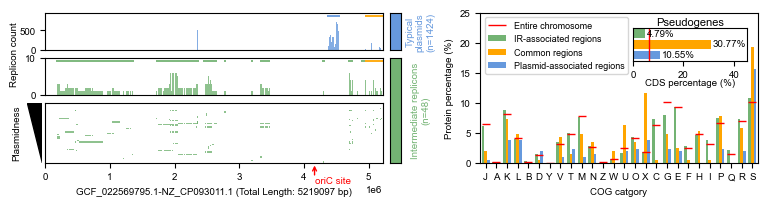

In [7]:
fig = plt.figure(figsize=(7.5, 7.5))

ax_left_site = 0.48-0.03
ax1 = fig.add_axes([0.05, 0.95, ax_left_site, 0.05])
ax2 = fig.add_axes([0.05, 0.89, ax_left_site, 0.05])
ax3 = fig.add_axes([0.05, 0.8, ax_left_site, 0.08])

bbox1 = ax1.get_position()
bbox2 = ax2.get_position()
bbox3 = ax3.get_position()

x0_1, y0_1, x1_1, y1_1 = bbox1.x0, bbox1.y0, bbox1.x1, bbox1.y1
x0_2, y0_2, x1_2, y1_2 = bbox2.x0, bbox2.y0, bbox2.x1, bbox2.y1
x0_3, y0_3, x1_3, y1_3 = bbox3.x0, bbox3.y0, bbox3.x1, bbox3.y1

COLOR_TYPICAL = "#6699dd"
COLOR_TRANS = "#73b373"

y_label_center = (y0_2 + y1_1) / 2
fig.text(
    x=0.015,
    y=y_label_center,
    s="Replicon count",
    fontsize=7,
    ha="right", va="center", rotation=90
)

tri_w = 0.02
ax_tri = fig.add_axes([x0_3 - tri_w - 0.004, y0_3, tri_w, y1_3 - y0_3])
ax_tri.set_xlim(0, 1)
ax_tri.set_ylim(0, 1)
ax_tri.axis("off")

tri_points = [
    [0, 1],
    [1, 1],
    [1, 0]
]
triangle = Polygon(tri_points, closed=True, color="black")
ax_tri.add_patch(triangle)

fig.text(
    x = x0_3 - tri_w - 0.018,
    y = (y0_3 + y1_3) / 2,
    s = "Plasmidness",
    fontsize = 7,
    ha = "center", va = "center",
    rotation = 90
)

# ax1: Typical plasmid
ax1.set_ylim(0, typical_coverage.max()*1.25)
for s, e, h in typical_regions:
    ax1.add_patch(plt.Rectangle((s, 0), e-s, h, color=COLOR_TYPICAL, alpha=0.8, linewidth=0))
ax1.set_xticks([])
ax1.set_xlim(0, seq_len)
for s, e in typical_unique:
    ax1.add_patch(plt.Rectangle((s, typical_coverage.max()*1.1), e-s, typical_coverage.max()*0.06, 
                                color=COLOR_TYPICAL, alpha=0.9, linewidth=0))
for s, e in common_intervals:
    ax1.add_patch(plt.Rectangle((s, typical_coverage.max()*1.1), e-s, typical_coverage.max()*0.06, 
                                color='orange', alpha=0.9, linewidth=0))

# ax2: Intermediate
ax2.set_ylim(0, trans_coverage.max()*1.25)
for s, e, h in trans_regions:
    ax2.add_patch(plt.Rectangle((s, 0), e-s, h, color=COLOR_TRANS, alpha=0.8, linewidth=0))
ax2.set_xticks([])
ax2.set_xlim(0, seq_len)
for s, e in trans_unique:
    ax2.add_patch(plt.Rectangle((s, trans_coverage.max()*1.1), e-s, trans_coverage.max()*0.06, 
                                color=COLOR_TRANS, alpha=0.9, linewidth=0))
for s, e in common_intervals:
    ax2.add_patch(plt.Rectangle((s, trans_coverage.max()*1.1), e-s, trans_coverage.max()*0.06, 
                                color='orange', alpha=0.9, linewidth=0))

for order, (sid, score) in enumerate(zip(transi_score_df['accession'], transi_score_df['average plasmid fraction-pident_90'])):
    df_sub = temp_result[temp_result['sseqid'] == sid]
    for _, row in df_sub.iterrows():
        qs, qe = row['qstart'], row['qend']
        w = qe - qs
        ax3.add_patch(plt.Rectangle((qs, order-0.5), w, 1, color=COLOR_TRANS, alpha=0.8, linewidth=0))

ax3.set_xlabel(f'{max_name}-{seq_record_id} (Total Length: {seq_len} bp)')
ax3.set_ylim(-0.5, len(transi_score_df)-0.5)
ax3.set_yticks([])
ax3.set_xlim(0, seq_len)
ax3.annotate(
    '',
    xy=(oric_site, -0.5),
    xytext=(oric_site, -len(transi_score_df)*0.25-0.5),
    arrowprops=dict(arrowstyle='->', color='red', lw=1)
)

#ax3.plot([oric_site, oric_site], [-0.5, -1.0], color='red', linewidth=1.5)
ax3.text(oric_site, -len(transi_score_df)*0.23-0.5, 'oriC site', color='red', va='top')

leg_w = 0.015
gap = 0.01

leg1_x = x1_1 + gap
leg1_y = y0_1
leg1_h = y1_1 - y0_1
ax_leg1 = fig.add_axes([leg1_x, leg1_y, leg_w, leg1_h])
ax_leg1.add_patch(plt.Rectangle((0,0), 1, 1, color=COLOR_TYPICAL))
ax_leg1.set_xticks([])
ax_leg1.set_yticks([])
text1 = fig.text(leg1_x + leg_w + 0.025, leg1_y + leg1_h/2, f"Typical\nplasmids\n(n={len(typical_score_df)})", fontsize=7, va="center", ha='center', rotation=90, color=COLOR_TYPICAL)

fig.canvas.draw()
bbox = text1.get_window_extent(renderer=fig.canvas.get_renderer())
fig_bbox = bbox.transformed(fig.transFigure.inverted())

x0 = fig_bbox.x0
y0 = fig_bbox.y0
x1 = fig_bbox.x1
y1 = fig_bbox.y1
#print(x0, y0, x1, y1)

leg2_x = x1_2 + gap
leg2_y = y0_3
leg2_h = y1_2 - y0_3
ax_leg2 = fig.add_axes([leg2_x, leg2_y, leg_w, leg2_h])
ax_leg2.add_patch(plt.Rectangle((0,0), 1, 1, color=COLOR_TRANS))
ax_leg2.set_yticks([])
ax_leg2.set_xticks([])
fig.text(leg2_x + leg_w + 0.025, leg2_y + leg2_h/2, f"Intermediate replicons\n(n={len(transi_score_df)})", fontsize=7, va="center", ha='center', rotation=90, color=COLOR_TRANS)

gene_stat_x = leg2_x + 0.12
gene_stat_height = y1_1 - y0_3
ax_gene_stat = fig.add_axes([gene_stat_x, leg2_y, 1-(gene_stat_x), gene_stat_height])
plot_cog_categories(ax_gene_stat, region_gene_data)
ax_psudo_stat = fig.add_axes([gene_stat_x + (1-(gene_stat_x))*0.55, leg2_y + gene_stat_height*0.68, (1-(gene_stat_x))*0.41, gene_stat_height*0.22])
plot_pseudo_genes(ax_psudo_stat, region_gene_data)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig(f"{genus_name}_NMS_MS_link_example1{suffix}.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{genus_name}_NMS_MS_link_example1{suffix}.png", dpi=1000, bbox_inches="tight", transparent=True)

#fig.patches.append(Rectangle((0,0),1,1,transform=fig.transFigure,fill=False,lw=2))
plt.show()